# Encontro 7. As quatro técnicas de sorteio e a distribuição amostral

**Disciplina:** Métodos e Técnicas de Pesquisa Quantitativa — Administração/UFMA
**Docente:** Prof. Dr. Tadeu Gomes Teixeira

> **O que você vai fazer hoje**
> 1. **Executar** as células de cima para baixo.
> 2. **Mudar dois valores**: o tamanho da amostra e o número de amostras simuladas.
> 3. **Escrever** a frase da estimativa, no fim.

---

## Painel do encontro

A **Parte 1** ensina as quatro técnicas probabilísticas sobre o mesmo cadastro de ontem.
A **Parte 2** responde a pergunta que fica: se eu sortear **mil** amostras, como as
estimativas se distribuíram?

| Item | Valor |
|---|---|
| **Fonte** | ANP — Série Histórica de Preços de Combustíveis (SHPC) |
| **Cadastro** | Maranhão, 2025, gasolina comum: **236 postos** |
| **Preço médio da população** | **R$ 6,0087** (o valor verdadeiro, aqui conhecido) |
| **Desvio padrão da população** | **R$ 0,3402** |

> **Por que este exercício é raro.** Em pesquisa de verdade, o valor verdadeiro da
> população é **desconhecido** — é justamente ele que se quer estimar. Aqui ele é
> conhecido, e por isso a turma consegue **ver** o erro de amostragem acontecer. É o
> único momento do semestre em que isso é possível.

## Bloco de configuração

```python
# --- o que você pode mudar ---
N_AMOSTRA = 50     # o tamanho de cada amostra
N_VEZES   = 1000   # quantas amostras simular
```

In [1]:
N_AMOSTRA = 50     # o tamanho de cada amostra
N_VEZES   = 1000   # quantas amostras simular

print(f"{N_VEZES} amostras de {N_AMOSTRA} postos")

1000 amostras de 50 postos


## Utilitários da disciplina

`conferir` compara o seu resultado com o número do slide. **Não precisa alterá-la.**

In [2]:

# =====================================================================
#  UTILITARIOS DA DISCIPLINA - nao precisa alterar nada daqui para baixo
#  estas duas funcoes sao usadas pelas celulas do encontro. Se voce nao
#  sabe o que elas fazem, tudo bem: nao mexa. Voce so precisa executar.
# =====================================================================

def conferir(descricao, obtido, esperado, tolerancia=0.005, unidade="%"):
    """Confere o resultado calculado contra o valor ja resolvido no slide.

    Chame assim:  conferir("taxa de sobrevivencia do setor X", obtido, 0.412)

    O 'esperado' e o numero que ja estava escrito no slide, resolvido a mao
    pelo professor. Se aparecer [ok], o seu calculo esta certo. Se aparecer
    [X], confira a base, o filtro e a coluna que voce usou.
    """
    try:
        dif = abs(float(obtido) - float(esperado))
    except (TypeError, ValueError):
        print("  [X ] nao deu para comparar: obtido = %r" % (obtido,))
        return
    num = lambda v: ("%.*f%s" % (2, v, unidade)) if unidade else ("%.4f" % v)
    if dif <= tolerancia:
        print("  [ok] %-54s obtido %-9s esperado %s"
              % (descricao[:54], num(float(obtido)), num(float(esperado))))
    else:
        print("  [X ] %-54s obtido %-9s esperado %-9s dif %s"
              % (descricao[:54], num(float(obtido)), num(float(esperado)), num(dif)))


def cartao(df, coluna, nome_base="base"):
    """Imprime o contexto que voce precisa colar no assistente de IA.

    Chame assim:  cartao(dados, "porte")

    Copie a saida inteira e cole no pedido. E isso que impede a IA de
    inventar numero: ela so pode usar o que esta escrito no cartao.
    """
    print("=== CARTAO DE CONTEXTO (copie tudo daqui para o assistente) ===")
    print("base: %s" % nome_base)
    print("linhas x colunas: %d x %d" % df.shape)
    print("colunas e seu significado:")
    for c in df.columns:
        print("   - %s (%s)" % (c, df[c].dtype))
    if coluna in df.columns:
        print("valores unicos de '%s': %s"
              % (coluna, sorted(map(str, df[coluna].dropna().unique()))[:25]))
    print("=== fim do cartao ===")


print("Utilitarios carregados: conferir() e cartao() estao prontas para uso.")


Utilitarios carregados: conferir() e cartao() estao prontas para uso.


## Seção 1. O cadastro e o valor verdadeiro

A base é a mesma do encontro 6. O que muda é o uso: agora não vamos apenas sortear
<em>uma</em> amostra — vamos sortear **mil**, e olhar a distribuição das estimativas.

> **O valor verdadeiro está ao lado, e isso é uma raridade.** Em pesquisa real, ninguém
> sabe o preço médio da população: é ele que se estima. Aqui ele é conhecido, e é o que
> permite medir o erro.

In [3]:
# ================= O cadastro e a população do exercício =================
# O mesmo cadastro do encontro 6: um registro por posto, com o preço do ano.

import pandas as pd

URL = ("https://raw.githubusercontent.com/tadeugomes/"
       "metodos-pesquisa-quantitativa/main/dados/anp_precos_revenda_ma_2025.csv")

try:
    anp = pd.read_csv(URL)
except Exception:
    # enquanto o repositório não tem o arquivo, ou se a internet falhar:
    # o caminho local do repositório. No Colab, faça upload do CSV se precisar.
    anp = pd.read_csv("dados/anp_precos_revenda_ma_2025.csv")

gas = anp[anp["produto"] == "GASOLINA"].dropna(subset=["valor_venda"])
cadastro = (gas.sort_values("mes_arquivo")
               .drop_duplicates("cnpj_da_revenda", keep="first")
               [["cnpj_da_revenda", "municipio", "valor_venda"]]
               .rename(columns={"valor_venda": "preco_medio"})
               .reset_index(drop=True))

populacao = cadastro["preco_medio"]
print(f"População: {len(populacao)} postos")
print(f"  média (o parâmetro) = R$ {populacao.mean():.4f}")
print(f"  desvio padrão        = R$ {populacao.std():.4f}")

População: 236 postos
  média (o parâmetro) = R$ 6.0087
  desvio padrão        = R$ 0.3402


## Parte 2 · Estatística: a distribuição amostral

**A ideia do bloco.** Uma estimativa é uma **variável aleatória**: ela tem distribuição,
centro e largura. E é a largura dessa distribuição — e não a dos dados originais — que
vira a margem de erro de uma pesquisa.

$$EP = \frac{s}{\sqrt{n}}$$

* $s$ é o desvio padrão da população
* $n$ é o tamanho da amostra
* $EP$ é o erro padrão da média

Em corrente: **a estimativa varia menos que os dados**, e varia menos ainda conforme a
amostra cresce — mas pela **raiz** de n. Para reduzir o erro pela metade, quadruplique a
amostra.

**Quando usar e quando não usar**

| | |
|---|---|
| **Use** | O erro padrão para dizer quanto a estimativa pode variar. É ele que entra na margem de erro e no intervalo de confiança |
| **Não use** | O desvio padrão da população como se fosse a incerteza da estimativa. O desvio descreve **os casos**; o erro padrão descreve **a estimativa** |

In [4]:
# A simulação: mil amostras, mil estimativas.
import numpy as np

medias = np.array([cadastro["preco_medio"].sample(n=N_AMOSTRA,
                                                  random_state=s).mean()
                   for s in range(N_VEZES)])

erro_padrao = populacao.std() / N_AMOSTRA ** 0.5

print(f"{N_VEZES} amostras de {N_AMOSTRA} postos")
print()
print(f"  o valor verdadeiro (parâmetro) ...... R$ {populacao.mean():.4f}")
print(f"  centro das {N_VEZES} estimativas ....... R$ {medias.mean():.4f}")
print(f"     diferença ......................... {medias.mean() - populacao.mean():+.4f}")
print()
print(f"  largura observada (desvio das médias) R$ {medias.std():.4f}")
print(f"  largura prevista (s ÷ √n) .......... R$ {erro_padrao:.4f}")
print(f"     diferença ......................... {medias.std() - erro_padrao:+.4f}")
print()
print(f"  a variação dos PREÇOS (R$ {populacao.std():.4f}) é "
      f"{populacao.std() / medias.std():.1f} vezes a variação das ESTIMATIVAS")
print()
print("Duas leituras:")
print("  o centro mostra que a estimativa não é viciada;")
print("  a largura mostra que ela varia — e o quanto.")

conferir("média da população", populacao.mean(), 6.0087, tolerancia=0.001, unidade=" R$")
conferir("erro padrão previsto", erro_padrao, 0.0481, tolerancia=0.001, unidade=" R$")

1000 amostras de 50 postos

  o valor verdadeiro (parâmetro) ...... R$ 6.0087
  centro das 1000 estimativas ....... R$ 6.0082
     diferença ......................... -0.0005

  largura observada (desvio das médias) R$ 0.0418
  largura prevista (s ÷ √n) .......... R$ 0.0481
     diferença ......................... -0.0063

  a variação dos PREÇOS (R$ 0.3402) é 8.1 vezes a variação das ESTIMATIVAS

Duas leituras:
  o centro mostra que a estimativa não é viciada;
  a largura mostra que ela varia — e o quanto.
  [ok] média da população                                     obtido 6.01 R$   esperado 6.01 R$
  [ok] erro padrão previsto                                   obtido 0.05 R$   esperado 0.05 R$


In [5]:
# A regra 68-95-99,7 aplicada às estimativas.
dentro = lambda k: (np.abs(medias - populacao.mean()) < k * erro_padrao).mean() * 100

print("Quantas das mil estimativas caem a k erros padrão do valor verdadeiro:")
for k, esperado in [(1, 68.3), (2, 95.4), (3, 99.7)]:
    print(f"  k = {k}: observado {dentro(k):5.1f}%  |  a regra diz {esperado:5.1f}%  "
          f"|  diferença {dentro(k) - esperado:+.1f}")
print()
print("É a mesma régua do encontro 4, agora sobre ESTIMATIVAS em vez de preços.")
print("No próximo encontro ela vira o intervalo de confiança.")

Quantas das mil estimativas caem a k erros padrão do valor verdadeiro:
  k = 1: observado  74.8%  |  a regra diz  68.3%  |  diferença +6.5
  k = 2: observado  98.2%  |  a regra diz  95.4%  |  diferença +2.8
  k = 3: observado  99.9%  |  a regra diz  99.7%  |  diferença +0.2

É a mesma régua do encontro 4, agora sobre ESTIMATIVAS em vez de preços.
No próximo encontro ela vira o intervalo de confiança.


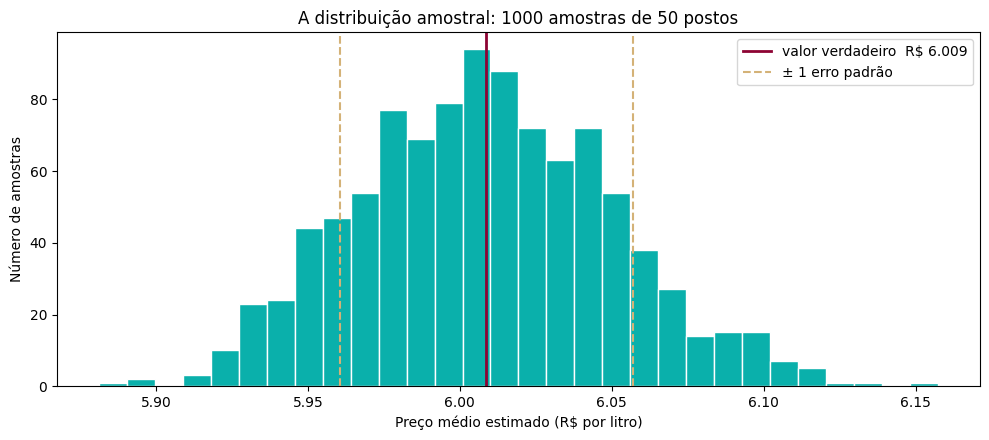

A forma é aproximadamente normal, e o centro está no valor verdadeiro.
É o teorema central do limite, na frente de vocês.


In [6]:
# O histograma das estimativas: a distribuição amostral, desenhada.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(medias, bins=30, color="#0AB0AB", edgecolor="white")
ax.axvline(populacao.mean(), color="#8D0333", linewidth=2,
           label=f"valor verdadeiro  R$ {populacao.mean():.3f}")
ax.axvline(populacao.mean() - erro_padrao, color="#D4B277", linewidth=1.5,
           linestyle="--")
ax.axvline(populacao.mean() + erro_padrao, color="#D4B277", linewidth=1.5,
           linestyle="--", label="± 1 erro padrão")
ax.set_xlabel("Preço médio estimado (R$ por litro)")
ax.set_ylabel("Número de amostras")
ax.set_title(f"A distribuição amostral: {N_VEZES} amostras de {N_AMOSTRA} postos")
ax.legend()
plt.tight_layout()
plt.show()

print("A forma é aproximadamente normal, e o centro está no valor verdadeiro.")
print("É o teorema central do limite, na frente de vocês.")

**A frase que vai para o relatório**

> "O preço médio dos postos do Maranhão é de **R$ 6,01**, e uma amostra de 50 postos
> estima esse valor com um **erro padrão de R$ 0,05** — ou seja, estimativas de amostras
> desse tamanho variam cerca de R$ 0,10 para cima ou para baixo na maioria das vezes
> (ANP, SHPC, 2025)."

**O que essa frase não diz.** Que a estimativa está errada. O erro padrão não é um erro
cometido: é a **variação esperada** da estimativa. Uma estimativa a um erro padrão do valor
verdadeiro é o comportamento normal — só acima de dois é que se estranha.

## Seção 2. As três perguntas do dia

Responda por escrito, editando as células abaixo.

**1. Se você quadruplicar o tamanho da amostra, o que acontece com o erro padrão? E por quê?**

_(dica: olhe a fórmula, e depois teste no notebook)_

---


**2. No seu projeto, qual seria a diferença entre o desvio padrão da sua variável e o erro padrão da sua estimativa?**

---


**3. O centro das mil estimativas ficou praticamente no valor verdadeiro. O que isso mostra, e o que uma amostra por conveniência mudaria nesse resultado?**

---


## Antes de sair

- [ ] Executei o notebook inteiro de cima para baixo, sem erro
- [ ] Mudei `N_AMOSTRA` e `N_VEZES` e vi a largura mudar
- [ ] Entendo a diferença entre desvio padrão e erro padrão
- [ ] Respondi as três perguntas

> Guarde este notebook. **No próximo encontro o erro padrão vira intervalo de confiança**,
> e é ele que fecha o Módulo II.